# AI Guard — XGBoost Training Notebook (Kaggle Edition)

**Spec**: 02 - Model Training & Evaluation (v1.1)
**Environment**: Kaggle Notebook
**Model**: XGBoost (binary classifier: `normal` vs `anomalous`)

---

### Catatan Penting Sebelum Menjalankan

1. **Dataset**: Notebook ini mengharapkan 3 file mentah CSIC 2010 sudah ditambahkan sebagai *Kaggle Dataset* di panel kanan (`+ Add Input`):
   - `normalTrafficTraining.txt`
   - `normalTrafficTest.txt`
   - `anomalousTrafficTest.txt`

   Ketiganya digabung terlebih dahulu (`normalTrafficTraining` + `normalTrafficTest` → label `normal`, `anomalousTrafficTest` → label `anomalous`), **baru** dilakukan `train_test_split` dengan `stratify=y` sesuai permintaan Anda — bukan memakai split bawaan dataset.

2. **Parser & Feature Extractor mandiri**: Spec 02 aslinya mengasumsikan import dari `src.feature_extraction` (hasil Spec 01). Karena Spec 01 belum tersedia dan notebook ini harus jalan sendiri di Kaggle (tanpa repo eksternal), **parser HTTP CSIC 2010, dataset loader, dan 32-fitur feature extractor diimplementasikan langsung di notebook ini** (Section 2 & 6), didokumentasikan lengkap. Jika Anda nanti punya modul Spec 01 resmi, tinggal ganti Section 6 dengan importnya — struktur output (`X, y, feature_names`) sudah dibuat kompatibel.

3. **Parameter tuning**: semua parameter yang biasa diubah-ubah (path data, random seed, hyperparameter baseline XGBoost, ruang pencarian Optuna, jumlah trial, dsb) dikumpulkan dalam **satu tabel konfigurasi di Section 1** supaya mudah diatur tanpa scroll ke bawah.

4. Jalankan sel dari atas ke bawah (`Run All`). Total waktu berjalan tergantung jumlah trial Optuna yang Anda set.


## Section 1: Setup, Konfigurasi & Tabel Parameter Tuning

In [18]:
# Install dependency yang mungkin belum ada di image Kaggle (aman dijalankan berulang)
import sys, subprocess

def _ensure(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

_ensure("optuna")
_ensure("xgboost")
print("Dependencies OK.")


Dependencies OK.


In [19]:
# ============================================================
# IMPORTS
# ============================================================
import os
import re
import json
import math
import glob
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve
)

import xgboost as xgb
import optuna
import joblib

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style("whitegrid")
print("Imports OK.")


Imports OK.


In [20]:
# ============================================================
# 1.A KONFIGURASI DASAR (silakan sesuaikan)
# ============================================================

# --- Lokasi data ---
# Di Kaggle, dataset yang di-attach lewat "Add Input" akan muncul di /kaggle/input/<nama-dataset>/
# Kita auto-detect folder yang berisi ketiga file CSIC 2010 supaya tidak perlu tahu nama dataset persis.
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

REQUIRED_FILES = [
    "normalTrafficTraining.txt",
    "normalTrafficTest.txt",
    "anomalousTrafficTest.txt",
]

def find_data_dir(root: Path, required_files):
    '''Cari folder di bawah `root` yang memuat ketiga file wajib.'''
    if not root.exists():
        return None
    for dirpath, _, filenames in os.walk(root):
        if all(f in filenames for f in required_files):
            return Path(dirpath)
    return None

DATA_DIR = find_data_dir(KAGGLE_INPUT_ROOT, REQUIRED_FILES)

if DATA_DIR is None:
    # Fallback untuk eksperimen lokal / non-Kaggle: ubah manual jika perlu
    DATA_DIR = Path("./sample/training")
    print(f"[WARNING] Dataset CSIC tidak ditemukan otomatis di {KAGGLE_INPUT_ROOT}. "
          f"Menggunakan fallback path: {DATA_DIR}. Pastikan dataset sudah di-Add Input di Kaggle.")
else:
    print(f"Dataset ditemukan di: {DATA_DIR}")

OUTPUT_DIR = Path("/kaggle/working/models") if Path("/kaggle/working").exists() else Path("./models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2   # proporsi test set setelah SEMUA data digabung

print(f"Output directory : {OUTPUT_DIR}")
print(f"Random state      : {RANDOM_STATE}")
print(f"Test size         : {TEST_SIZE}")


Dataset ditemukan di: /kaggle/input/datasets/wicaksonohanifs/network-traffic-data
Output directory : /kaggle/working/models
Random state      : 42
Test size         : 0.2


### 1.B Tabel Parameter Tuning (edit di sini saja)

Semua nilai di bawah adalah satu-satunya tempat yang perlu Anda ubah untuk eksperimen ulang:

| Kelompok | Parameter | Default | Keterangan |
|---|---|---|---|
| Baseline XGBoost | `max_depth` | 6 | kedalaman pohon |
| Baseline XGBoost | `learning_rate` | 0.1 | laju belajar |
| Baseline XGBoost | `n_estimators` | 200 | jumlah pohon |
| Baseline XGBoost | `subsample` | 0.8 | fraksi sampel per pohon |
| Baseline XGBoost | `colsample_bytree` | 0.8 | fraksi fitur per pohon |
| Baseline XGBoost | `min_child_weight` | 3 | regularisasi split |
| Baseline XGBoost | `gamma` | 0 | minimum loss reduction |
| Baseline XGBoost | `reg_alpha` | 0.1 | L1 regularization |
| Baseline XGBoost | `reg_lambda` | 1.0 | L2 regularization |
| Optuna | `N_TRIALS` | 50 | jumlah trial pencarian |
| Optuna | `CV_FOLDS` | 5 | jumlah fold Stratified K-Fold |
| Optuna | rentang `max_depth` | 3–15 | batas pencarian |
| Optuna | rentang `learning_rate` | 0.01–0.3 (log-scale) | batas pencarian |
| Optuna | rentang `n_estimators` | 100–500 | batas pencarian |
| Optuna | rentang `subsample` | 0.5–1.0 | batas pencarian |
| Optuna | rentang `colsample_bytree` | 0.5–1.0 | batas pencarian |
| Optuna | rentang `min_child_weight` | 1–10 | batas pencarian |
| Optuna | rentang `gamma` | 0–5 | batas pencarian |
| Optuna | rentang `reg_alpha` | 0–1 | batas pencarian |
| Optuna | rentang `reg_lambda` | 0–1 | batas pencarian |
| Optuna | rentang `scale_pos_weight` | 0.5–2.0 | penyeimbang kelas |
| Threshold tuning | rentang threshold | 0.1–0.9 (step 0.01) | pencarian threshold optimal |


In [21]:
# ============================================================
# TABEL PARAMETER TUNING — bentuk kode (sumber kebenaran / source of truth)
# Ubah nilai di sini, seluruh notebook di bawah akan otomatis memakainya.
# ============================================================

# --- 1) Baseline hyperparameters (dipakai di Section 8) ---
BASELINE_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "gamma": 0,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
}

# --- 2) Optuna search space (dipakai di Section 10) ---
# format: (tipe, low, high, extra_kwargs_dict)
#   tipe "int"   -> trial.suggest_int(name, low, high, **extra)
#   tipe "float" -> trial.suggest_float(name, low, high, **extra)
OPTUNA_SEARCH_SPACE = {
    "max_depth":         ("int",   3,    15,  {}),
    "learning_rate":      ("float", 0.01, 0.3, {"log": True}),
    "n_estimators":       ("int",   100,  500, {}),
    "subsample":          ("float", 0.5,  1.0, {}),
    "colsample_bytree":   ("float", 0.5,  1.0, {}),
    "min_child_weight":   ("int",   1,    10,  {}),
    "gamma":              ("float", 0,    5,   {}),
    "reg_alpha":          ("float", 0,    1,   {}),
    "reg_lambda":         ("float", 0,    1,   {}),
    "scale_pos_weight":   ("float", 0.5,  2.0, {}),
}

N_TRIALS = 50          # jumlah trial Optuna — turunkan (mis. 15-20) untuk iterasi cepat di Kaggle
CV_FOLDS = 5            # jumlah fold StratifiedKFold (dipakai di CV & objective Optuna)
OPTUNA_SCORING = "f1_weighted"   # metric yang dioptimasi Optuna

# --- 3) Threshold tuning range (dipakai di Section 13) ---
THRESHOLD_RANGE = np.arange(0.1, 0.9, 0.01)

# Tampilkan ringkas sebagai DataFrame supaya mudah dicek sebelum run
display(pd.DataFrame([BASELINE_PARAMS]).T.rename(columns={0: "value"}))


,value
objective,binary:logistic
eval_metric,logloss
max_depth,6
learning_rate,0.1
n_estimators,200
subsample,0.8
colsample_bytree,0.8
min_child_weight,3
gamma,0
reg_alpha,0.1


## Section 2: HTTP Request Parser (format CSIC 2010)

Format mentah CSIC 2010 (sesuai contoh data Anda) menulis method dan URL dalam **satu baris**:

```
POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1
User-Agent: Mozilla/5.0 ...
...
Content-Length: 146

id=2&nombre=...&cantidad=...

GET http://localhost:8080/tienda1/publico/anadir.jsp?id=2%2F&... HTTP/1.1
User-Agent: Mozilla/5.0 ...
...
Connection: close


POST http://localhost:8080/... HTTP/1.1
...
```

**Poin penting (sumber bug pembacaan sebelumnya)**: jumlah baris kosong antar-request **berbeda tergantung ada/tidaknya body**:
- Request dengan body (POST): `... body_line` diikuti **1 baris kosong**, lalu langsung baris request berikutnya.
- Request tanpa body (GET): setelah header terakhir ada **2 baris kosong** berturut-turut (1 baris kosong penutup header + 1 baris kosong pemisah antar-request), baru baris request berikutnya.

Parser di bawah mendeteksi awal request baru dengan memeriksa **token pertama** dari baris non-kosong berikutnya (bukan mencocokkan seluruh baris) — sehingga baris seperti `"GET http://... HTTP/1.1"` maupun `"POST http://... HTTP/1.1"` tetap terdeteksi sebagai awal request baru, terlepas dari berapa banyak baris kosong sebelumnya.


In [23]:
from urllib.parse import urlsplit

HTTP_METHODS = {"GET", "POST", "PUT", "DELETE", "HEAD", "OPTIONS", "PATCH", "TRACE", "CONNECT"}


class HTTPRequestParser:
    '''Parser untuk raw HTTP request log format CSIC 2010.'''

    @staticmethod
    def parse_raw_text(raw_text: str):
        '''Parse seluruh isi file (banyak request) menjadi list of dict terstruktur.'''
        # Normalisasi line ending
        raw_text = raw_text.replace("\r\n", "\n")
        lines = raw_text.split("\n")

        requests = []
        current_lines = []

        def flush():
            if current_lines:
                parsed = HTTPRequestParser._parse_single(current_lines)
                if parsed is not None:
                    requests.append(parsed)

        i = 0
        n = len(lines)
        while i < n:
            line = lines[i]
            if line.strip() == "":
                # Cek apakah baris non-kosong berikutnya adalah AWAL request baru.
                # Jumlah baris kosong sebelum request berikutnya bisa 1 (setelah body POST)
                # atau 2+ (setelah header GET tanpa body) -> keduanya harus dilewati sama-sama.
                j = i + 1
                while j < n and lines[j].strip() == "":
                    j += 1
                is_new_request = False
                if j < n:
                    next_line_stripped = lines[j].strip()
                    first_token = next_line_stripped.split(None, 1)[0].upper() if next_line_stripped else ""
                    is_new_request = first_token in HTTP_METHODS
                if is_new_request:
                    # akhir dari request saat ini; lewati SEMUA baris kosong sekaligus
                    flush()
                    current_lines = []
                    i = j
                    continue
                else:
                    # blank line adalah pemisah header/body dalam request yang sama -> simpan
                    current_lines.append(line)
                    i += 1
                    continue
            else:
                current_lines.append(line)
                i += 1
        flush()
        return requests

    @staticmethod
    def _parse_single(block_lines):
        '''Parse satu blok baris menjadi dict request. Return None jika tidak valid.'''
        # buang leading/trailing blank lines
        while block_lines and block_lines[0].strip() == "":
            block_lines = block_lines[1:]
        while block_lines and block_lines[-1].strip() == "":
            block_lines = block_lines[:-1]
        if not block_lines:
            return None

        method_line = block_lines[0].strip()

        # Kasus 1: format "METHOD url HTTP/1.1" dalam satu baris
        method, full_url = None, None
        m = re.match(r"^(GET|POST|PUT|DELETE|HEAD|OPTIONS|PATCH|TRACE|CONNECT)\s+(\S+)(\s+HTTP/\d\.\d)?$",
                     method_line, re.IGNORECASE)
        idx_after_request_line = 1
        if m:
            method = m.group(1).upper()
            full_url = m.group(2)
        else:
            # Kasus 2 (format asli CSIC): baris 1 = method saja, baris 2 = full url
            if method_line.upper() in HTTP_METHODS and len(block_lines) > 1:
                method = method_line.upper()
                full_url = block_lines[1].strip()
                idx_after_request_line = 2
            else:
                return None  # tidak bisa diparse, skip

        if not full_url:
            return None

        # Sisa baris: header sampai ketemu blank line, setelah itu body
        headers = {}
        body_lines = []
        in_body = False
        for line in block_lines[idx_after_request_line:]:
            if not in_body and line.strip() == "":
                in_body = True
                continue
            if in_body:
                body_lines.append(line)
            else:
                if ":" in line:
                    key, _, value = line.partition(":")
                    headers[key.strip().lower()] = value.strip()
        body = "\n".join(body_lines).strip()

        # Pecah URL menjadi path (relatif, tanpa scheme/host) + query string + query params
        url_parts = urlsplit(full_url)
        if url_parts.scheme and url_parts.netloc:
            path = url_parts.path or "/"
            query_string = url_parts.query
        elif "?" in full_url:
            # full_url tanpa scheme/host (mis. relative path), fallback split manual
            path, query_string = full_url.split("?", 1)
        else:
            path, query_string = full_url, ""

        query_params = HTTPRequestParser._parse_query_string(query_string)

        # Untuk POST, body juga sering berupa form-urlencoded params -> gabungkan ke query_params
        # sebagai representasi payload (tanpa menghapus body mentahnya)
        if method == "POST" and body and "=" in body:
            body_params = HTTPRequestParser._parse_query_string(body)
            merged_params = dict(query_params)
            merged_params.update(body_params)
        else:
            merged_params = query_params

        content_length = 0
        if "content-length" in headers:
            try:
                content_length = int(headers["content-length"])
            except ValueError:
                content_length = len(body)
        else:
            content_length = len(body)

        return {
            "method": method,
            "full_url": full_url,
            "path": path,
            "query_string": query_string,
            "query_params": merged_params,
            "headers": headers,
            "body": body,
            "content_length": content_length,
        }

    @staticmethod
    def _parse_query_string(qs: str):
        params = {}
        if not qs:
            return params
        for pair in qs.split("&"):
            if not pair:
                continue
            if "=" in pair:
                k, v = pair.split("=", 1)
            else:
                k, v = pair, ""
            params[k] = v
        return params


## Section 3: Dataset Loader (3 file → gabung → 1 DataFrame)

Menyesuaikan permintaan Anda:
- `normalTrafficTraining.txt` + `normalTrafficTest.txt` → label **normal**
- `anomalousTrafficTest.txt` → label **anomalous**
- Ketiganya **digabung dulu** menjadi satu DataFrame besar. Split train/test stratified baru dilakukan setelah ini (Section 8), **bukan** memakai pembagian train/test bawaan nama file.


In [24]:
class CSICDatasetLoader:
    '''Loader untuk 3 file mentah CSIC 2010 (format Kaggle upload Anda).'''

    FILE_LABEL_MAP = {
        "normalTrafficTraining.txt": "normal",
        "normalTrafficTest.txt": "normal",
        "anomalousTrafficTest.txt": "anomalous",
    }

    def __init__(self, data_dir: Path, file_label_map: dict = None):
        self.data_dir = Path(data_dir)
        self.file_label_map = file_label_map or self.FILE_LABEL_MAP

    def load(self) -> pd.DataFrame:
        records = []
        counts = Counter()
        for filename, label in self.file_label_map.items():
            filepath = self.data_dir / filename
            if not filepath.exists():
                print(f"[WARNING] File tidak ditemukan, dilewati: {filepath}")
                continue
            raw_text = filepath.read_text(encoding="latin-1", errors="ignore")
            parsed_requests = HTTPRequestParser.parse_raw_text(raw_text)
            for parsed in parsed_requests:
                records.append({
                    "label": label,
                    "source_file": filename,
                    "parsed_json": parsed,
                })
            counts[label] += len(parsed_requests)
            print(f"  Loaded {len(parsed_requests):>6} requests from {filename:<28} -> label='{label}'")

        df = pd.DataFrame(records)
        print(f"\nTotal requests loaded: {len(df)}  ({dict(counts)})")
        return df


loader = CSICDatasetLoader(data_dir=DATA_DIR)
df = loader.load()


  Loaded  36000 requests from normalTrafficTraining.txt    -> label='normal'
  Loaded  36000 requests from normalTrafficTest.txt        -> label='normal'
  Loaded  25065 requests from anomalousTrafficTest.txt     -> label='anomalous'

Total requests loaded: 97065  ({'normal': 72000, 'anomalous': 25065})


## Section 4: Ringkasan Dataset Gabungan

In [25]:
print(f"Total samples: {len(df)}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nDistribusi per source_file:\n{df.groupby(['source_file', 'label']).size()}")
print(f"\nContoh 1 parsed request:")
print(json.dumps(df["parsed_json"].iloc[0], indent=2)[:1500])


Total samples: 97065

Class distribution:
label
normal       72000
anomalous    25065
Name: count, dtype: int64

Distribusi per source_file:
source_file                label    
anomalousTrafficTest.txt   anomalous    25065
normalTrafficTest.txt      normal       36000
normalTrafficTraining.txt  normal       36000
dtype: int64

Contoh 1 parsed request:
{
  "method": "GET",
  "full_url": "http://localhost:8080/tienda1/index.jsp",
  "path": "/tienda1/index.jsp",
  "query_string": "",
  "query_params": {},
  "headers": {
    "user-agent": "Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)",
    "pragma": "no-cache",
    "cache-control": "no-cache",
    "accept": "text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5",
    "accept-encoding": "x-gzip, x-deflate, gzip, deflate",
    "accept-charset": "utf-8, utf-8;q=0.5, *;q=0.5",
    "accept-language": "en",
    "host": "localhost:8080",
    "cookie": "JSESSIONID=1F767F1723

## Section 5: Exploratory Data Analysis (EDA)

### 5.1 Distribusi Request Method

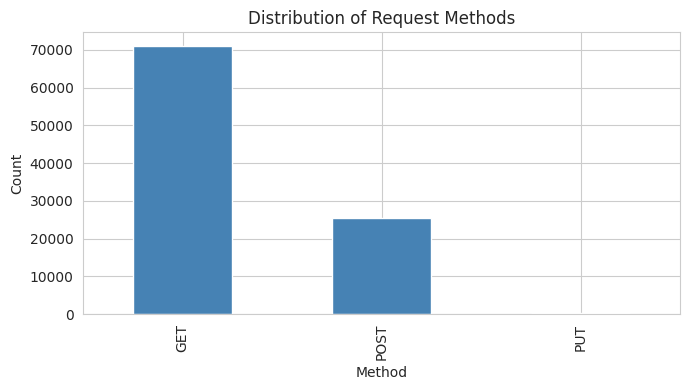

In [26]:
plt.figure(figsize=(7, 4))
df["parsed_json"].apply(lambda x: x["method"]).value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Request Methods")
plt.xlabel("Method")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 5.2 Analisis Panjang URL per Kelas

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
anomalous,25065.0,97.611769,91.574349,22.0,48.0,55.0,113.0,886.0
normal,72000.0,70.001333,59.455457,39.0,48.0,49.5,58.0,363.0


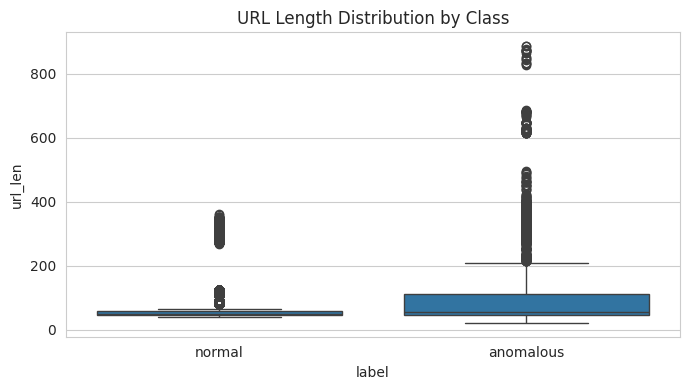

In [27]:
df["url_len"] = df["parsed_json"].apply(lambda x: len(x["full_url"]))
display(df.groupby("label")["url_len"].describe())

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="url_len")
plt.title("URL Length Distribution by Class")
plt.tight_layout()
plt.show()


### 5.3 Analisis Payload Body

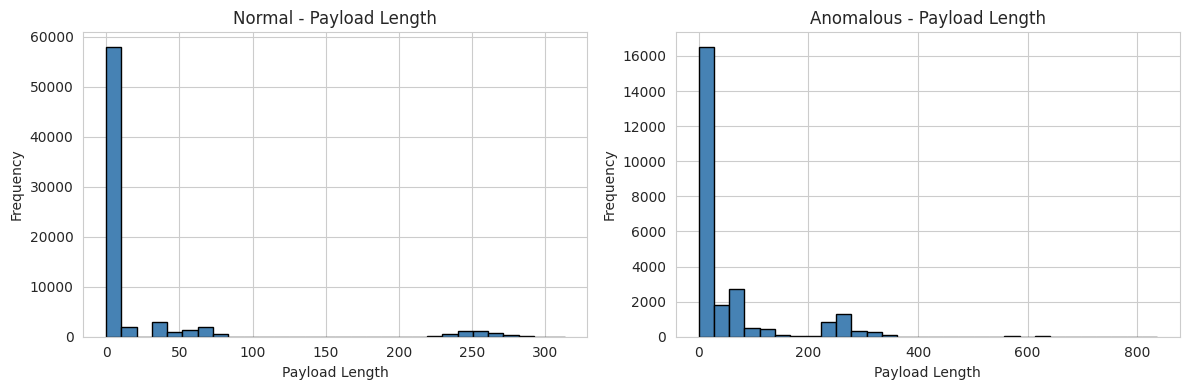

In [29]:
df["payload_len"] = df["parsed_json"].apply(lambda x: len(x["body"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, ax in zip(["normal", "anomalous"], axes):
    subset = df[df["label"] == label]["payload_len"]
    ax.hist(subset, bins=30, edgecolor="black", color="steelblue")
    ax.set_title(f"{label.capitalize()} - Payload Length")
    ax.set_xlabel("Payload Length")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5.4 Analisis Jumlah Query Parameter

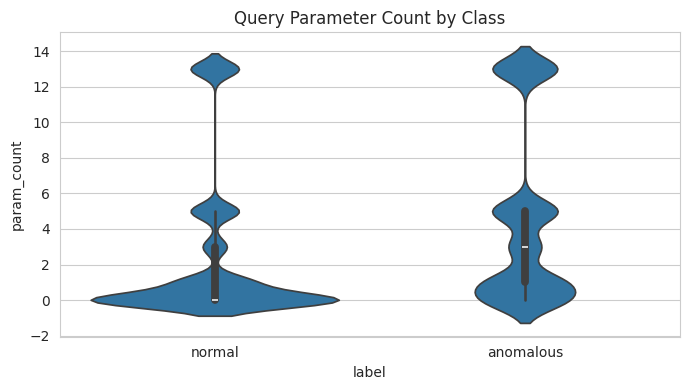

In [30]:
df["param_count"] = df["parsed_json"].apply(lambda x: len(x.get("query_params", {})))

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x="label", y="param_count")
plt.title("Query Parameter Count by Class")
plt.tight_layout()
plt.show()


### 5.5 Analisis Kehadiran Header Umum

In [31]:
common_headers = ["user-agent", "host", "cookie", "content-type", "accept"]

header_presence = {}
for header in common_headers:
    header_presence[f"has_{header}"] = df["parsed_json"].apply(
        lambda x: 1 if header in x.get("headers", {}) else 0
    )

header_df = pd.DataFrame(header_presence)
header_df = pd.concat([header_df, df["label"]], axis=1)

for header in common_headers:
    ct = pd.crosstab(df["label"], header_df[f"has_{header}"])
    print(f"\n{'='*40}")
    print(f"Header: {header}")
    print(ct)



Header: user-agent
has_user-agent      1
label                
anomalous       25065
normal          72000

Header: host
has_host       1
label           
anomalous  25065
normal     72000

Header: cookie
has_cookie      1
label            
anomalous   25065
normal      72000

Header: content-type
has_content-type      0      1
label                         
anomalous         15088   9977
normal            56000  16000

Header: accept
has_accept      1
label            
anomalous   25065
normal      72000


### 5.6 Deteksi Keyword SQL pada Raw Text

In [32]:
SQL_KEYWORDS_PATTERN = re.compile(
    r"(SELECT|UNION|INSERT|UPDATE|DELETE|DROP|ALTER|CREATE|"
    r"EXEC|EXECUTE|xp_|sp_|DECLARE|CURSOR|CAST|CONVERT|"
    r"OR\s+1\s*=\s*1|AND\s+1\s*=\s*1)",
    re.IGNORECASE
)

df["raw_sql_match"] = df["parsed_json"].apply(
    lambda x: 1 if SQL_KEYWORDS_PATTERN.search(x["full_url"] + x["body"]) else 0
)

print(f"Raw SQL keyword matches in normal:    {(df[df['label']=='normal']['raw_sql_match'] == 1).sum()}")
print(f"Raw SQL keyword matches in anomalous: {(df[df['label']=='anomalous']['raw_sql_match'] == 1).sum()}")


Raw SQL keyword matches in normal:    6534
Raw SQL keyword matches in anomalous: 3848


### 5.7 Ringkasan Statistik

In [33]:
summary_stats = df.groupby("label").agg(
    count=("label", "count"),
    avg_url_len=("url_len", "mean"),
    max_url_len=("url_len", "max"),
    avg_payload_len=("payload_len", "mean"),
    max_payload_len=("payload_len", "max"),
    avg_param_count=("param_count", "mean")
).round(2)
display(summary_stats)


,count,avg_url_len,max_url_len,avg_payload_len,max_payload_len,avg_param_count
label,,,,,,
anomalous,25065,97.61,886,48.58,836,4.46
normal,72000,70.00,363,20.36,313,2.33


## Section 6: Feature Extraction (32 fitur)

> **Catatan asumsi**: karena Spec 01 (Feature Extraction) belum tersedia saat notebook ini dibuat, 32 fitur di bawah **dirancang mandiri** berdasarkan literatur deteksi anomali HTTP umum (length-based, entropy-based, keyword/signature-based, structural). Jika Anda memiliki daftar fitur resmi dari Spec 01, silakan ganti isi method `FeatureExtractor.extract()` — struktur output (`X`, `y`, `feature_names`) sudah kompatibel dengan Section 7 dan seterusnya.

| # | Fitur | Kategori | Keterangan |
|---|---|---|---|
| 1 | `url_length` | Length | panjang total URL |
| 2 | `path_length` | Length | panjang path |
| 3 | `query_string_length` | Length | panjang query string |
| 4 | `body_length` | Length | panjang body |
| 5 | `num_headers` | Length | jumlah header |
| 6 | `num_params` | Length | jumlah query/body parameter |
| 7 | `avg_param_name_length` | Param stats | rata-rata panjang nama parameter |
| 8 | `avg_param_value_length` | Param stats | rata-rata panjang nilai parameter |
| 9 | `max_param_value_length` | Param stats | nilai parameter terpanjang |
| 10 | `max_param_name_length` | Param stats | nama parameter terpanjang |
| 11 | `std_param_value_length` | Param stats | std dev panjang nilai parameter |
| 12 | `url_entropy` | Entropy | Shannon entropy dari full URL |
| 13 | `body_entropy` | Entropy | Shannon entropy dari body |
| 14 | `param_value_max_entropy` | Entropy | entropy tertinggi di antara semua nilai parameter |
| 15 | `digit_ratio` | Char composition | rasio digit pada (url+body) |
| 16 | `uppercase_ratio` | Char composition | rasio huruf kapital |
| 17 | `special_char_ratio` | Char composition | rasio karakter non-alfanumerik |
| 18 | `alpha_ratio` | Char composition | rasio huruf |
| 19 | `whitespace_count` | Char composition | jumlah whitespace |
| 20 | `non_printable_count` | Char composition | jumlah karakter non-printable |
| 21 | `sql_keyword_count` | Signature | jumlah match keyword SQLi |
| 22 | `xss_keyword_count` | Signature | jumlah match pattern XSS |
| 23 | `path_traversal_count` | Signature | jumlah match `../`, `..\\`, dsb |
| 24 | `crlf_injection_count` | Signature | jumlah match `%0d%0a`, `\r\n` di payload |
| 25 | `cmd_injection_count` | Signature | jumlah match keyword command injection |
| 26 | `file_inclusion_count` | Signature | jumlah match pattern LFI/RFI |
| 27 | `encoded_char_count` | Signature | jumlah pattern `%XX` (URL-encoding) |
| 28 | `method_is_get` | Structural | binary, 1 jika method GET |
| 29 | `method_is_post` | Structural | binary, 1 jika method POST |
| 30 | `has_cookie_header` | Structural | binary, header cookie ada |
| 31 | `has_content_type_header` | Structural | binary, header content-type ada |
| 32 | `content_length_mismatch` | Structural | selisih absolut antara header `Content-Length` dan panjang body aktual |


In [34]:
def shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    return -sum((c / length) * math.log2(c / length) for c in counts.values())


XSS_PATTERN = re.compile(r"(<script|javascript:|onerror\s*=|onload\s*=|<img|<iframe|alert\s*\(|document\.cookie)", re.IGNORECASE)
PATH_TRAVERSAL_PATTERN = re.compile(r"(\.\./|\.\.\\|%2e%2e%2f|%2e%2e/|\.\.%2f)", re.IGNORECASE)
CRLF_PATTERN = re.compile(r"(%0d%0a|%0d|%0a|\r\n)", re.IGNORECASE)
CMD_INJECTION_PATTERN = re.compile(r"(;|\||&&|`|\$\(|wget\s|curl\s|nc\s|/bin/sh|/bin/bash|cmd\.exe)", re.IGNORECASE)
FILE_INCLUSION_PATTERN = re.compile(r"(\betc/passwd\b|\bboot\.ini\b|php://|file://|include\s*\(|require\s*\()", re.IGNORECASE)
ENCODED_CHAR_PATTERN = re.compile(r"%[0-9A-Fa-f]{2}")


class FeatureExtractor:
    '''Ekstraksi 32 fitur numerik dari satu parsed request dict.'''

    FEATURE_NAMES = [
        "url_length", "path_length", "query_string_length", "body_length",
        "num_headers", "num_params",
        "avg_param_name_length", "avg_param_value_length", "max_param_value_length",
        "max_param_name_length", "std_param_value_length",
        "url_entropy", "body_entropy", "param_value_max_entropy",
        "digit_ratio", "uppercase_ratio", "special_char_ratio", "alpha_ratio",
        "whitespace_count", "non_printable_count",
        "sql_keyword_count", "xss_keyword_count", "path_traversal_count",
        "crlf_injection_count", "cmd_injection_count", "file_inclusion_count",
        "encoded_char_count",
        "method_is_get", "method_is_post", "has_cookie_header",
        "has_content_type_header", "content_length_mismatch",
    ]

    def extract(self, parsed: dict) -> list:
        full_url = parsed.get("full_url", "") or ""
        path = parsed.get("path", "") or ""
        query_string = parsed.get("query_string", "") or ""
        body = parsed.get("body", "") or ""
        headers = parsed.get("headers", {}) or {}
        params = parsed.get("query_params", {}) or {}
        method = (parsed.get("method", "") or "").upper()

        combined_text = full_url + body

        # --- Length-based ---
        url_length = len(full_url)
        path_length = len(path)
        query_string_length = len(query_string)
        body_length = len(body)
        num_headers = len(headers)
        num_params = len(params)

        # --- Param stats ---
        param_names = list(params.keys())
        param_values = [str(v) for v in params.values()]
        name_lens = [len(n) for n in param_names] or [0]
        value_lens = [len(v) for v in param_values] or [0]

        avg_param_name_length = float(np.mean(name_lens))
        avg_param_value_length = float(np.mean(value_lens))
        max_param_value_length = float(np.max(value_lens))
        max_param_name_length = float(np.max(name_lens))
        std_param_value_length = float(np.std(value_lens))

        # --- Entropy ---
        url_entropy = shannon_entropy(full_url)
        body_entropy = shannon_entropy(body)
        param_value_max_entropy = max((shannon_entropy(v) for v in param_values), default=0.0)

        # --- Char composition ---
        n_chars = max(len(combined_text), 1)
        digit_ratio = sum(c.isdigit() for c in combined_text) / n_chars
        uppercase_ratio = sum(c.isupper() for c in combined_text) / n_chars
        alpha_ratio = sum(c.isalpha() for c in combined_text) / n_chars
        special_char_ratio = sum((not c.isalnum()) and (not c.isspace()) for c in combined_text) / n_chars
        whitespace_count = sum(c.isspace() for c in combined_text)
        non_printable_count = sum(not c.isprintable() for c in combined_text)

        # --- Signature-based counts ---
        sql_keyword_count = len(SQL_KEYWORDS_PATTERN.findall(combined_text))
        xss_keyword_count = len(XSS_PATTERN.findall(combined_text))
        path_traversal_count = len(PATH_TRAVERSAL_PATTERN.findall(combined_text))
        crlf_injection_count = len(CRLF_PATTERN.findall(combined_text))
        cmd_injection_count = len(CMD_INJECTION_PATTERN.findall(combined_text))
        file_inclusion_count = len(FILE_INCLUSION_PATTERN.findall(combined_text))
        encoded_char_count = len(ENCODED_CHAR_PATTERN.findall(combined_text))

        # --- Structural ---
        method_is_get = 1 if method == "GET" else 0
        method_is_post = 1 if method == "POST" else 0
        has_cookie_header = 1 if "cookie" in headers else 0
        has_content_type_header = 1 if "content-type" in headers else 0

        declared_len = parsed.get("content_length", 0) or 0
        content_length_mismatch = abs(declared_len - len(body))

        return [
            url_length, path_length, query_string_length, body_length,
            num_headers, num_params,
            avg_param_name_length, avg_param_value_length, max_param_value_length,
            max_param_name_length, std_param_value_length,
            url_entropy, body_entropy, param_value_max_entropy,
            digit_ratio, uppercase_ratio, special_char_ratio, alpha_ratio,
            whitespace_count, non_printable_count,
            sql_keyword_count, xss_keyword_count, path_traversal_count,
            crlf_injection_count, cmd_injection_count, file_inclusion_count,
            encoded_char_count,
            method_is_get, method_is_post, has_cookie_header,
            has_content_type_header, content_length_mismatch,
        ]

    def extract_batch(self, df: pd.DataFrame):
        feature_rows = df["parsed_json"].apply(self.extract).tolist()
        X = np.array(feature_rows, dtype=float)
        y = (df["label"] == "anomalous").astype(int).to_numpy()
        return X, y, self.FEATURE_NAMES


extractor = FeatureExtractor()
print("Extracting features...")
X, y, feature_names = extractor.extract_batch(df)

print(f"Extracted {len(feature_names)} features successfully")
print(f"Shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

feature_df = pd.DataFrame(X, columns=feature_names)
feature_df["label"] = y
print(f"\nFeature matrix shape: {feature_df.shape}")
display(feature_df.head())


Extracting features...
Extracted 32 features successfully
Shape: X=(97065, 32), y=(97065,)
Class distribution: {np.int64(0): np.int64(72000), np.int64(1): np.int64(25065)}

Feature matrix shape: (97065, 33)


,url_length,path_length,query_string_length,body_length,num_headers,num_params,avg_param_name_length,avg_param_value_length,max_param_value_length,max_param_name_length,...,crlf_injection_count,cmd_injection_count,file_inclusion_count,encoded_char_count,method_is_get,method_is_post,has_cookie_header,has_content_type_header,content_length_mismatch,label
0,39.0,18.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,117.0,27.0,68.0,0.0,10.0,5.0,4.8,7.0,19.0,8.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0
2,48.0,27.0,0.0,68.0,12.0,5.0,4.8,7.0,19.0,8.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0
3,116.0,31.0,63.0,0.0,10.0,5.0,4.4,6.4,11.0,8.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0
4,52.0,31.0,0.0,63.0,12.0,5.0,4.4,6.4,11.0,8.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0


## Section 7: Sanity Check Fitur

In [35]:
assert X.shape[1] == 32, f"Expected 32 features, got {X.shape[1]}"
assert not np.isnan(X).any(), "Ditemukan NaN pada feature matrix"
assert set(np.unique(y)) <= {0, 1}, "Label harus biner 0/1"
print("Sanity check OK: 32 fitur, tanpa NaN, label biner (0=normal, 1=anomalous).")


Sanity check OK: 32 fitur, tanpa NaN, label biner (0=normal, 1=anomalous).


## Section 8: Train/Test Split (Stratified, dari data gabungan)

Sesuai instruksi Anda: **semua data (3 file) sudah digabung di Section 3**, baru di sini dilakukan `train_test_split` dengan `stratify=y`.


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test label distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")


Training set: 77652 samples
Test set:     19413 samples

Train label distribution: {np.int64(0): np.int64(57600), np.int64(1): np.int64(20052)}
Test label distribution:  {np.int64(0): np.int64(14400), np.int64(1): np.int64(5013)}


## Section 9: Baseline Model (Default Hyperparameters)

In [37]:
baseline_model = xgb.XGBClassifier(**BASELINE_PARAMS)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

accuracy_baseline = baseline_model.score(X_test, y_test)
auc_baseline = roc_auc_score(y_test, y_proba_baseline)

print("Baseline Model Performance:")
print(f"  Accuracy: {accuracy_baseline:.4f}")
print(f"  ROC-AUC:  {auc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=["normal", "anomalous"]))


Baseline Model Performance:
  Accuracy: 0.9748
  ROC-AUC:  0.9963

Classification Report:
              precision    recall  f1-score   support

      normal       0.97      1.00      0.98     14400
   anomalous       0.99      0.91      0.95      5013

    accuracy                           0.97     19413
   macro avg       0.98      0.96      0.97     19413
weighted avg       0.98      0.97      0.97     19413



## Section 10: Cross-Validation

In [38]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores_f1 = cross_val_score(baseline_model, X_train, y_train, cv=skf, scoring="f1_weighted")
cv_scores_auc = cross_val_score(baseline_model, X_train, y_train, cv=skf, scoring="roc_auc")

print("Cross-Validation Results (Baseline):")
print(f"  F1 Weighted: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std():.4f})")
print(f"  ROC AUC:     {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std():.4f})")


Cross-Validation Results (Baseline):
  F1 Weighted: 0.9741 (+/- 0.0006)
  ROC AUC:     0.9963 (+/- 0.0002)


## Section 11: Hyperparameter Tuning dengan Optuna

Memakai `OPTUNA_SEARCH_SPACE`, `N_TRIALS`, dan `CV_FOLDS` yang sudah ditentukan pada tabel parameter tuning (Section 1.B).

In [39]:
def build_params_from_trial(trial, search_space):
    params = {}
    for name, (kind, low, high, extra) in search_space.items():
        if kind == "int":
            params[name] = trial.suggest_int(name, low, high, **extra)
        elif kind == "float":
            params[name] = trial.suggest_float(name, low, high, **extra)
        else:
            raise ValueError(f"Unknown param kind: {kind}")
    return params


def xgb_objective(trial):
    '''Objective function untuk Optuna hyperparameter tuning.'''
    params = build_params_from_trial(trial, OPTUNA_SEARCH_SPACE)
    params.update({
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
    })

    model = xgb.XGBClassifier(**params)
    skf_local = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=skf_local, scoring=OPTUNA_SCORING)
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best Trial:")
print(f"  Value:  {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

best_params = dict(study.best_params)
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
})


  0%|          | 0/50 [00:00<?, ?it/s]

Best Trial:
  Value:  0.9777
  Params: {'max_depth': 14, 'learning_rate': 0.06872210322284811, 'n_estimators': 165, 'subsample': 0.86986408399478, 'colsample_bytree': 0.8101105053100583, 'min_child_weight': 2, 'gamma': 0.2914596984103026, 'reg_alpha': 0.46549033252369604, 'reg_lambda': 0.3993646190072678, 'scale_pos_weight': 1.0880588102204576}


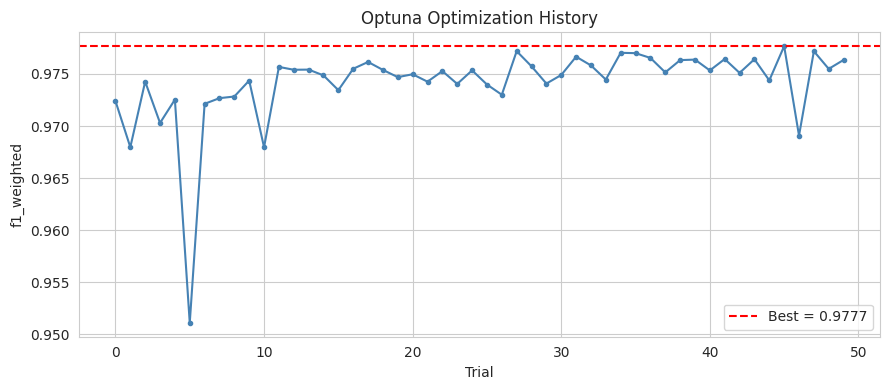

In [40]:
# Visualisasi progres optimasi Optuna
fig, ax = plt.subplots(figsize=(9, 4))
trial_values = [t.value for t in study.trials if t.value is not None]
ax.plot(trial_values, marker="o", markersize=3, color="steelblue")
ax.axhline(study.best_value, color="red", linestyle="--", label=f"Best = {study.best_value:.4f}")
ax.set_xlabel("Trial")
ax.set_ylabel(OPTUNA_SCORING)
ax.set_title("Optuna Optimization History")
ax.legend()
plt.tight_layout()
plt.show()


## Section 12: Final Model Training

In [41]:
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("FINAL MODEL PERFORMANCE (Best Hyperparameters)")
print("=" * 50)
print(f"Accuracy:  {final_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["normal", "anomalous"]))

print("\nCOMPARISON: Baseline vs Final Model")
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Baseline": [accuracy_baseline, auc_baseline],
    "Final": [final_model.score(X_test, y_test), roc_auc_score(y_test, y_proba_final)]
})
display(comparison)


FINAL MODEL PERFORMANCE (Best Hyperparameters)
Accuracy:  0.9791
ROC-AUC:   0.9977

Classification Report:
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99     14400
   anomalous       0.99      0.93      0.96      5013

    accuracy                           0.98     19413
   macro avg       0.98      0.96      0.97     19413
weighted avg       0.98      0.98      0.98     19413


COMPARISON: Baseline vs Final Model


,Metric,Baseline,Final
0,Accuracy,0.974811,0.979138
1,ROC-AUC,0.996290,0.997664


## Section 13: Evaluation Metrics & Visualizations

### 13.1 Confusion Matrix

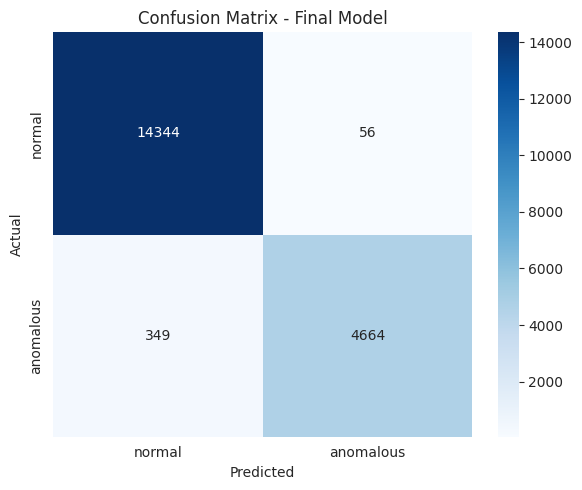

In [42]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "anomalous"],
            yticklabels=["normal", "anomalous"])
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()


### 13.2 ROC Curve

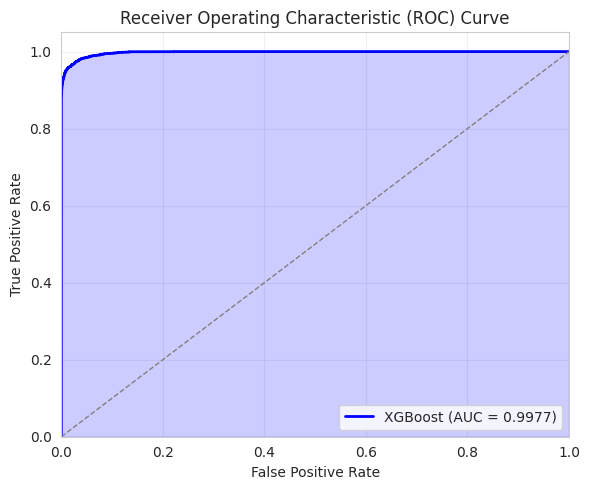

In [44]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc_value = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"XGBoost (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.fill_between(fpr, tpr, alpha=0.2, color="blue")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150)
plt.show()


### 13.3 Precision-Recall Curve

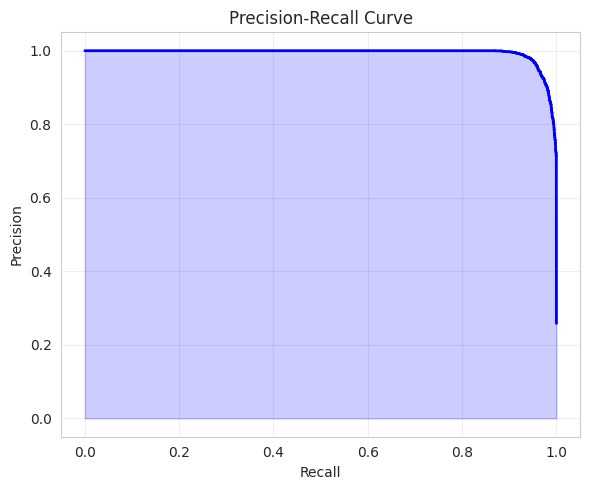

In [45]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_final)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, color="blue", lw=2)
plt.fill_between(recall_vals, precision_vals, alpha=0.2, color="blue")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_curve.png", dpi=150)
plt.show()


### 13.4 Feature Importance

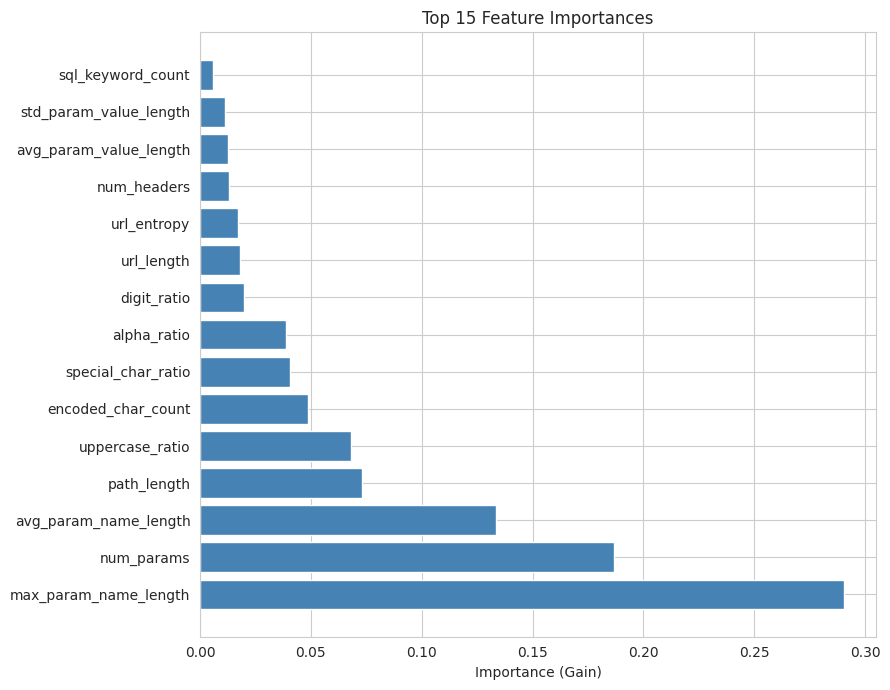


Top 10 Most Important Features:
              feature  importance
max_param_name_length    0.290335
           num_params    0.186777
avg_param_name_length    0.133359
          path_length    0.073162
      uppercase_ratio    0.068200
   encoded_char_count    0.048790
   special_char_ratio    0.040390
          alpha_ratio    0.038658
          digit_ratio    0.019647
           url_length    0.017897


In [46]:
importances = final_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 15
top_features = feat_imp.head(top_n)

plt.figure(figsize=(9, 7))
plt.barh(range(top_n), top_features["importance"].values[::-1], color="steelblue")
plt.yticks(range(top_n), top_features["feature"].values[::-1])
plt.xlabel("Importance (Gain)")
plt.title(f"Top {top_n} Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 Most Important Features:")
print(feat_imp.head(10).to_string(index=False))


## Section 14: Threshold Tuning (Optional)

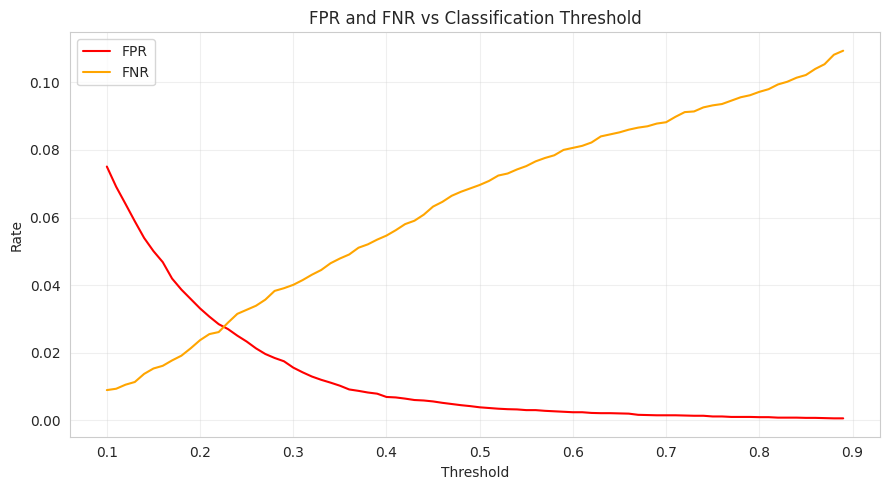

Suggested Threshold: 0.23
  FPR: 0.0270
  FNR: 0.0289


In [47]:
results = []
for threshold in THRESHOLD_RANGE:
    preds_tuned = (y_proba_final >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_tuned).ravel()
    fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_t = fn / (fn + tp) if (fn + tp) > 0 else 0
    results.append({
        "threshold": threshold,
        "fpr": fpr_t,
        "fnr": fnr_t,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0
    })

threshold_df = pd.DataFrame(results)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["fpr"], label="FPR", color="red")
plt.plot(threshold_df["threshold"], threshold_df["fnr"], label="FNR", color="orange")
plt.xlabel("Threshold"); plt.ylabel("Rate")
plt.title("FPR and FNR vs Classification Threshold")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

threshold_df["balance_score"] = abs(threshold_df["fpr"] - threshold_df["fnr"])
optimal_row = threshold_df.loc[threshold_df["balance_score"].idxmin()]
print(f"Suggested Threshold: {optimal_row['threshold']:.2f}")
print(f"  FPR: {optimal_row['fpr']:.4f}")
print(f"  FNR: {optimal_row['fnr']:.4f}")


## Section 15: Save Model & Metadata

In [48]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, OUTPUT_DIR / "xgboost_model.pkl")
print(f"Model saved to {OUTPUT_DIR / 'xgboost_model.pkl'}")

final_accuracy = final_model.score(X_test, y_test)
final_auc = roc_auc_score(y_test, y_proba_final)
final_report = classification_report(y_test, y_pred_final, output_dict=True, target_names=["normal", "anomalous"])

metadata = {
    "model_type": "XGBoost",
    "version": "1.0.0",
    "training_date": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "feature_names": feature_names,
    "num_features": len(feature_names),
    "hyperparameters": best_params,
    "baseline_hyperparameters": BASELINE_PARAMS,
    "optuna_config": {
        "n_trials": N_TRIALS,
        "cv_folds": CV_FOLDS,
        "scoring": OPTUNA_SCORING,
        "search_space": {k: list(v[:3]) for k, v in OPTUNA_SEARCH_SPACE.items()},
    },
    "dataset_info": {
        "total_samples": len(df),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "source_files": list(CSICDatasetLoader.FILE_LABEL_MAP.keys()),
        "data_directory": str(DATA_DIR),
        "combine_then_split": True,
    },
    "metrics": {
        "accuracy": float(final_accuracy),
        "roc_auc": float(final_auc),
        "precision_normal": float(final_report["normal"]["precision"]),
        "recall_normal": float(final_report["normal"]["recall"]),
        "f1_normal": float(final_report["normal"]["f1-score"]),
        "precision_anomalous": float(final_report["anomalous"]["precision"]),
        "recall_anomalous": float(final_report["anomalous"]["recall"]),
        "f1_anomalous": float(final_report["anomalous"]["f1-score"]),
    },
    "suggested_threshold": float(optimal_row["threshold"]),
    "feature_importance_top15": feat_imp.head(15).to_dict(orient="records"),
}

with open(OUTPUT_DIR / "xgboost_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to {OUTPUT_DIR / 'xgboost_metadata.json'}")
print("\n" + "=" * 50)
print("TRAINING COMPLETE!")
print("=" * 50)


Model saved to /kaggle/working/models/xgboost_model.pkl
Metadata saved to /kaggle/working/models/xgboost_metadata.json

TRAINING COMPLETE!


## Section 16: Acceptance Criteria Checklist (Spec 02)

Setelah menjalankan seluruh notebook, verifikasi:

- [ ] Notebook berjalan tanpa error dari awal sampai akhir (`Run All`)
- [ ] Dataset gabungan dari 3 file (`normalTrafficTraining.txt`, `normalTrafficTest.txt`, `anomalousTrafficTest.txt`) berhasil dibaca
- [ ] Semua data digabung dahulu, baru dilakukan stratified split (Section 3 → Section 8)
- [ ] Feature extraction menghasilkan **32 fitur**
- [ ] Model XGBoost terlatih, akurasi test set >= 95%
- [ ] Precision >= 94%, Recall >= 93%, F1 >= 93% untuk kelas `anomalous`
- [ ] False positive rate <= 2%
- [ ] Feature importance top-15 divisualisasikan
- [ ] Model tersimpan di `models/xgboost_model.pkl`
- [ ] Metadata tersimpan di `models/xgboost_metadata.json`
- [ ] Confusion matrix, ROC curve, PR curve, feature importance tersimpan sebagai `.png` di `models/`
- [ ] Reproducible dengan `RANDOM_STATE` tetap (42)

> Jika target metric pada Evaluasi (Accuracy >= 95%, ROC-AUC >= 0.98, dst) belum tercapai dengan fitur mandiri di notebook ini, pertimbangkan: (1) naikkan `N_TRIALS` Optuna, (2) tambah fitur signature baru sesuai kategori serangan yang under-detected (cek confusion matrix), atau (3) ganti Section 6 dengan feature extractor resmi dari Spec 01 begitu tersedia.
